In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path_images = 'Images/'

### 1. Détection + localisation d'objet (matching + homographie)

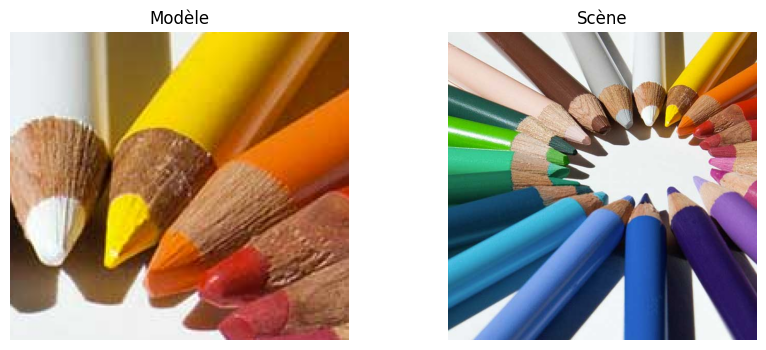

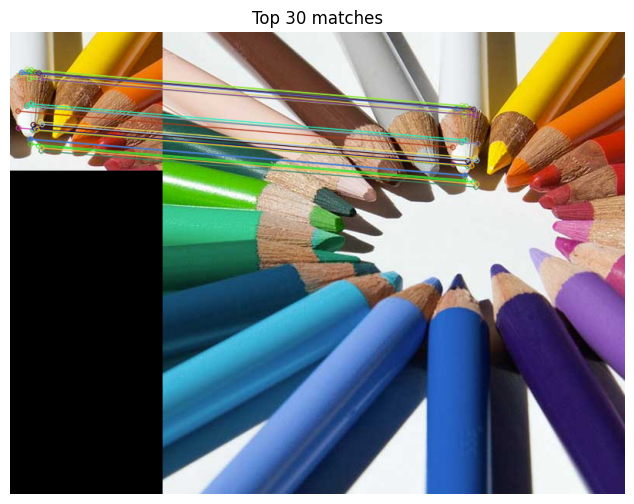

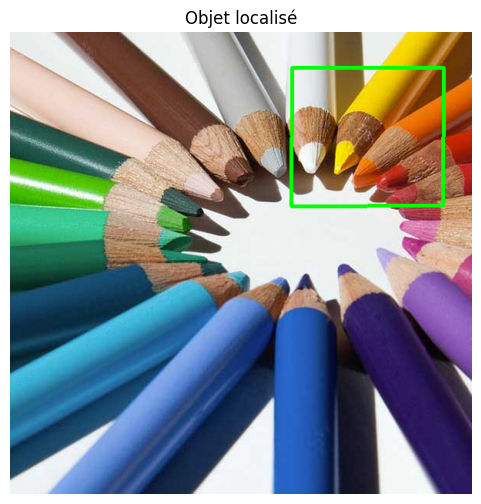

In [10]:
model = cv2.imread(path_images + "pattern.png", 1)
scene = cv2.imread(path_images + "crayons.jpg", 1)

gray_m = cv2.cvtColor(model, cv2.COLOR_BGR2GRAY)
gray_s = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp_m, des_m = sift.detectAndCompute(gray_m, None)
kp_s, des_s = sift.detectAndCompute(gray_s, None)

# FLANN + ratio test
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
matches = flann.knnMatch(des_m, des_s, k=2)
good = [m for m,n in matches if m.distance < 0.75 * n.distance]

# Visualisations
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(model, cv2.COLOR_BGR2RGB))
plt.title("Modèle")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
plt.title("Scène")
plt.axis('off')
plt.show()

# matches (top N)
N = min(30, len(good))
img_matches = cv2.drawMatches(model, kp_m, scene, kp_s, good[:N], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(14,6))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title(f"Top {N} matches")
plt.axis('off')
plt.show()

# homographie + polygone
if len(good) >= 10:
    src = np.float32([kp_m[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst = np.float32([kp_s[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    M, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    if M is not None:
        h,w = gray_m.shape
        corners = np.float32([[0,0],[0,h-1],[w-1,h-1],[w-1,0]]).reshape(-1,1,2)
        projected = cv2.perspectiveTransform(corners, M)
        out = scene.copy()
        cv2.polylines(out, [np.int32(projected)], True, (0,255,0), 3)
        plt.figure(figsize=(6,6)); plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        plt.title("Objet localisé")
        plt.axis('off')
        plt.show()
    else:
        print("Homographie introuvable.")
else:
    print(f"Pas assez de correspondances valides ({len(good)}) pour estimer une homographie.")

Matches valides: 77


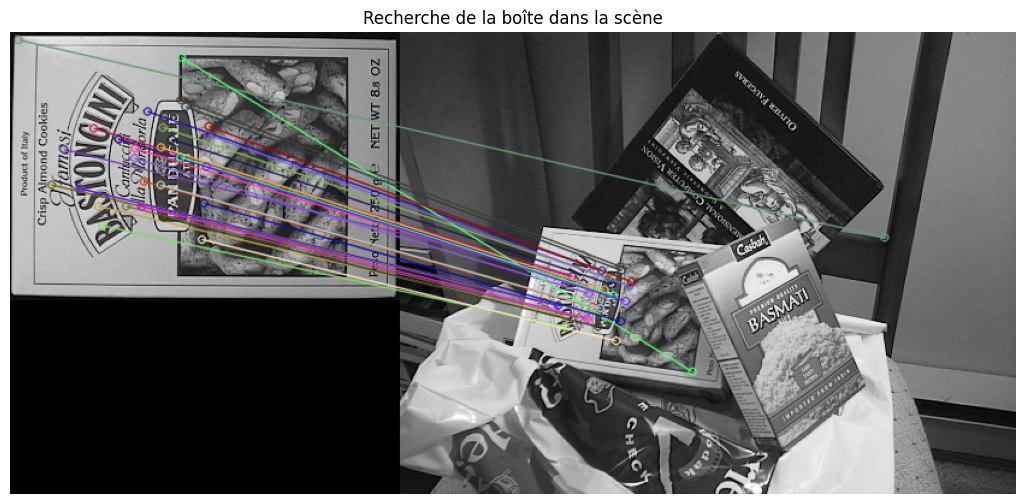

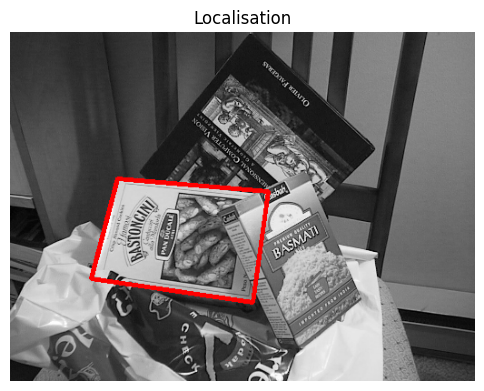

In [11]:
box = cv2.imread(path_images + "box.png", cv2.IMREAD_GRAYSCALE)
scene = cv2.imread(path_images + "box_in_scene.png", cv2.IMREAD_GRAYSCALE)
sift = cv2.SIFT_create()
kp_p, d_p = sift.detectAndCompute(box, None)
kp_s, d_s = sift.detectAndCompute(scene, None)

flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
matches = flann.knnMatch(d_p, d_s, k=2)
good = [m for m,n in matches if m.distance < 0.72 * n.distance]

print("Matches valides:", len(good))
N = min(30, len(good))
img_matches = cv2.drawMatches(box, kp_p, scene, kp_s, good[:N], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(14,6))
plt.imshow(img_matches, cmap='gray')
plt.title("Recherche de la boîte dans la scène")
plt.axis('off')
plt.show()

if len(good) >= 10:
    src = np.float32([kp_p[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst = np.float32([kp_s[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    M, _ = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    if M is not None:
        h,w = box.shape
        corners = np.float32([[0,0],[0,h-1],[w-1,h-1],[w-1,0]]).reshape(-1,1,2)
        proj = cv2.perspectiveTransform(corners, M)
        out = cv2.cvtColor(scene, cv2.COLOR_GRAY2BGR)
        cv2.polylines(out, [np.int32(proj)], True, (0,0,255), 3)
        plt.figure(figsize=(6,6)); plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); plt.title("Localisation"); plt.axis('off'); plt.show()

### 2. Panorama basique (deux images)

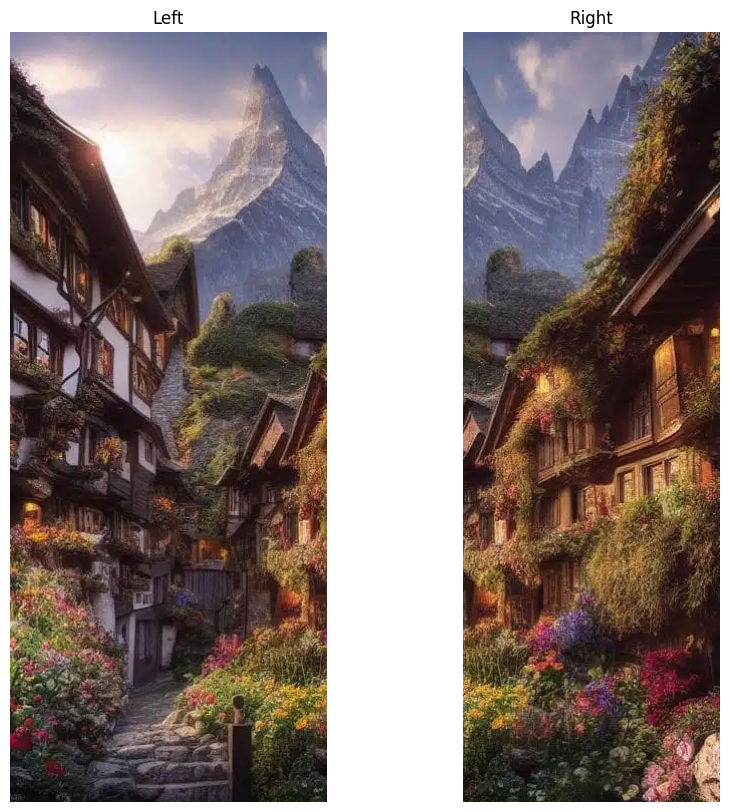

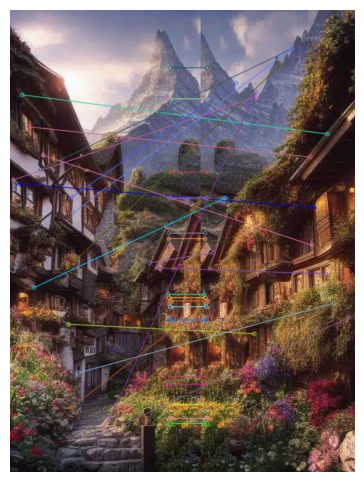

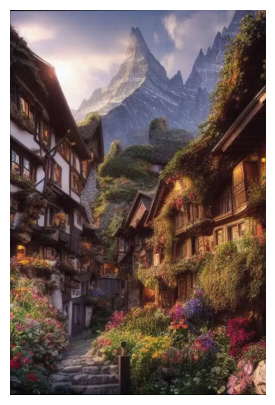

In [12]:
L = cv2.imread(path_images + "left_part.jpg", 1)
R = cv2.imread(path_images + "right_part.jpg", 1)

gL = cv2.cvtColor(L, cv2.COLOR_BGR2GRAY)
gR = cv2.cvtColor(R, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kpL, dL = sift.detectAndCompute(gL, None)
kpR, dR = sift.detectAndCompute(gR, None)

bf = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
#bf = cv2.BFMatcher()
matches = bf.knnMatch(dL, dR, k=2)
good = [m for m,n in matches if m.distance < 0.75 * n.distance]

# affichage sources et matches
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(L, cv2.COLOR_BGR2RGB))
plt.title("Left")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(R, cv2.COLOR_BGR2RGB))
plt.title("Right")
plt.axis('off')
plt.show()

N = min(40, len(good))
if N > 0:
    img_matches = cv2.drawMatches(L, kpL, R, kpR, good[:N], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(14,6))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

src = np.float32([kpL[m.queryIdx].pt for m in good]).reshape(-1,1,2)
dst = np.float32([kpR[m.trainIdx].pt for m in good]).reshape(-1,1,2)
H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
if H is None:
    print("Homographie introuvable.")
else:
    hL, wL = L.shape[:2]
    hR, wR = R.shape[:2]

    # calculer coins projetés de L et extents totaux
    corners_L = np.float32([[0,0],[0,hL],[wL,hL],[wL,0]]).reshape(-1,1,2)
    warped_corners = cv2.perspectiveTransform(corners_L, H)
    all_pts = np.vstack((warped_corners.reshape(-1,2), np.array([[0,0],[wR,0],[wR,hR],[0,hR]])))
    min_x, min_y = np.floor(all_pts.min(axis=0)).astype(int)
    max_x, max_y = np.ceil(all_pts.max(axis=0)).astype(int)

    tx = -min_x if min_x < 0 else 0
    ty = -min_y if min_y < 0 else 0
    out_w = max_x - min_x
    out_h = max_y - min_y

    # translation to keep everything positive
    T = np.array([[1, 0, tx],
                    [0, 1, ty],
                    [0, 0, 1]], dtype=float)
    Ht = T.dot(H)

    # warp left image
    panorama = cv2.warpPerspective(L, Ht, (out_w, out_h))

    # paste right image
    panorama[ty:ty+hR, tx:tx+wR] = np.where(
        (panorama[ty:ty+hR, tx:tx+wR] == 0),
        R,
        ((panorama[ty:ty+hR, tx:tx+wR].astype(np.float32) * 0.5 +
            R.astype(np.float32) * 0.5)).astype(np.uint8)
    )

    plt.figure(figsize=(12,5))
    plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [13]:
def find_best_match(features_list, base_features):
    """Trouve la meilleure image correspondante dans une liste."""
    base_kp, base_des = base_features
    best_match = {'index': -1, 'matches': [], 'score': -1}
    
    bf = cv2.BFMatcher()
    
    for i, (path, kp, des, img) in enumerate(features_list):
        if des is None or base_des is None or len(des) < 2 or len(base_des) < 2:
            continue
            
        matches = bf.knnMatch(des, base_des, k=2)
        
        good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
        
        if len(good_matches) > best_match['score']:
            best_match['score'] = len(good_matches)
            best_match['matches'] = good_matches
            best_match['index'] = i
            
    return best_match

def stitch(img1, img2, matches, kp1, kp2):
    if len(matches) < 10:
        print("Pas assez de correspondances pour assembler.")
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    if H is None:
        return None

    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    corners1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    corners2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)
    
    warped_corners1 = cv2.perspectiveTransform(corners1, H)
    all_corners = np.concatenate((warped_corners1, corners2), axis=0)

    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    translation_dist = [-x_min, -y_min]
    H_translation = np.array([[1, 0, translation_dist[0]], [0, 1, translation_dist[1]], [0, 0, 1]])

    output_img = cv2.warpPerspective(img1, H_translation.dot(H), (x_max - x_min, y_max - y_min))
    
    # Fusion avec blending simple
    roi = output_img[translation_dist[1]:h2 + translation_dist[1], translation_dist[0]:w2 + translation_dist[0]]
    mask_roi = roi > 0
    roi[~mask_roi] = img2[~mask_roi] # Copie les pixels où il n'y a pas de recouvrement
    roi[mask_roi] = cv2.addWeighted(roi, 0.5, img2, 0.5, 0)[mask_roi] # Moyenne sur le recouvrement
    
    return output_img

def create_panorama(image_paths, scale_factor=1, use_mask=False, border_width=100):
    sift = cv2.SIFT_create()
    
    features = []
    for path in image_paths:
        img = cv2.imread(path)
        if img is None:
            print(f"Impossible de lire l'image : {path}")
            continue
        
        # --- OPTIMISATION 1: Réduction de la résolution ---
        if scale_factor < 1.0:
            img = cv2.resize(img, (0, 0), fx=scale_factor, fy=scale_factor)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        mask = None
        # --- OPTIMISATION 2: Masque sur les bords ---
        if use_mask:
            mask = np.zeros(gray.shape, dtype=np.uint8)
            h, w = gray.shape
            mask[:border_width, :] = 255 # Haut
            mask[h-border_width:, :] = 255 # Bas
            mask[:, :border_width] = 255 # Gauche
            mask[:, w-border_width:] = 255 # Droite

        kp, des = sift.detectAndCompute(gray, mask=mask)
        
        # On doit remettre les keypoints à l'échelle originale si on a resizé
        if scale_factor < 1.0:
            for p in kp:
                p.pt = (p.pt[0] / scale_factor, p.pt[1] / scale_factor)
        
        # On relit l'image en pleine résolution pour l'assemblage final
        full_res_img = cv2.imread(path)
        features.append((path, kp, des, full_res_img))

    if len(features) < 2:
        print("Il faut au moins deux images.")
        return None

    unstitched = features.copy()
    base_path, base_kp, base_des, panorama = unstitched.pop(0)
    
    while len(unstitched) > 0:
        print(f"Images restantes à assembler : {len(unstitched)}")
        
        # Recalculer les features du panorama actuel (optimisé)
        pano_scaled = cv2.resize(panorama, (0,0), fx=scale_factor, fy=scale_factor) if scale_factor < 1.0 else panorama
        pano_gray = cv2.cvtColor(pano_scaled, cv2.COLOR_BGR2GRAY)
        pano_kp, pano_des = sift.detectAndCompute(pano_gray, None) # Pas de masque pour le panorama en cours
        if scale_factor < 1.0:
            for p in pano_kp:
                p.pt = (p.pt[0] / scale_factor, p.pt[1] / scale_factor)

        match_info = find_best_match(unstitched, (pano_kp, pano_des))
        
        if match_info['index'] == -1:
            print("Aucune correspondance trouvée. Arrêt de l'assemblage.")
            break
            
        match_path, match_kp, match_des, match_img = unstitched.pop(match_info['index'])
        print(f"Assemblage avec : {match_path} ({match_info['score']} correspondances)")
        
        new_panorama = stitch(match_img, panorama, match_info['matches'], match_kp, pano_kp)
        
        if new_panorama is None:
            print("L'assemblage a échoué. L'image sera ignorée.")
            continue
        
        panorama = new_panorama

    return panorama

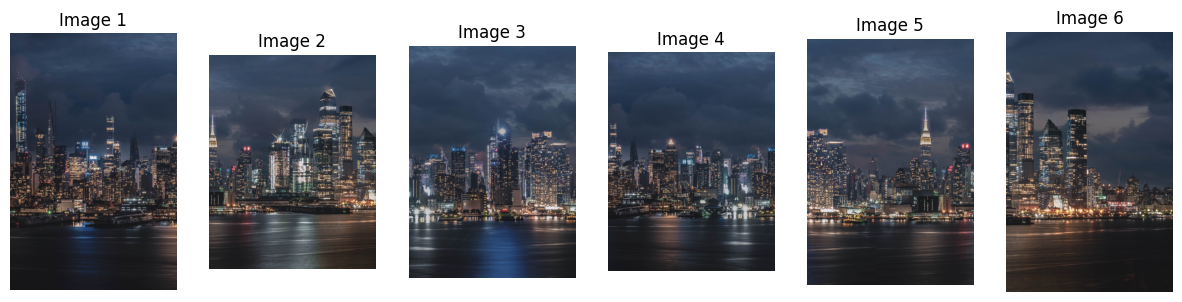

Images restantes à assembler : 5
Assemblage avec : Images/2.jpg (1382 correspondances)
Images restantes à assembler : 4
Assemblage avec : Images/2.jpg (1382 correspondances)
Images restantes à assembler : 4
Assemblage avec : Images/3.jpg (771 correspondances)
Images restantes à assembler : 3
Assemblage avec : Images/3.jpg (771 correspondances)
Images restantes à assembler : 3
Assemblage avec : Images/4.jpg (1335 correspondances)
Assemblage avec : Images/4.jpg (1335 correspondances)
Images restantes à assembler : 2
Images restantes à assembler : 2
Assemblage avec : Images/5.jpg (516 correspondances)
Assemblage avec : Images/5.jpg (516 correspondances)
Images restantes à assembler : 1
Images restantes à assembler : 1
Assemblage avec : Images/6.jpg (1024 correspondances)
Assemblage avec : Images/6.jpg (1024 correspondances)


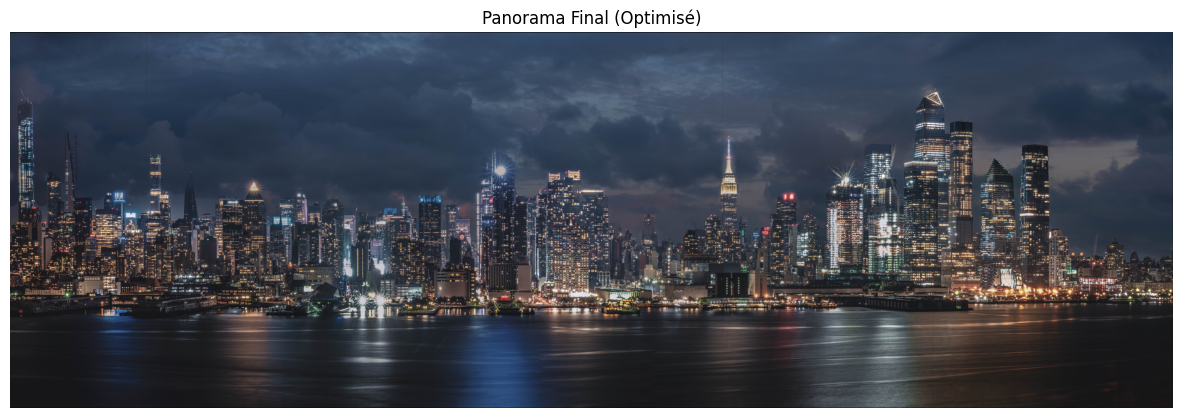

In [14]:
image_city = [path_images + '1.jpg',
               path_images + '5.jpg',
               path_images + '3.jpg',
               path_images + '2.jpg',
               path_images + '4.jpg',
               path_images + '6.jpg'
              ]

plt.figure(figsize=(15, 5))
for i in range(len(image_city)):
    plt.subplot(1, len(image_city), i+1)
    img = cv2.imread(image_city[i])
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Image {i+1}")
    plt.axis('off')
plt.show()

final_panorama = create_panorama(image_city, scale_factor=0.5, use_mask=True, border_width=150)

plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(final_panorama, cv2.COLOR_BGR2RGB))
plt.title("Panorama Final (Optimisé)")
plt.axis('off')
plt.show()

### 3. Recherche d'images

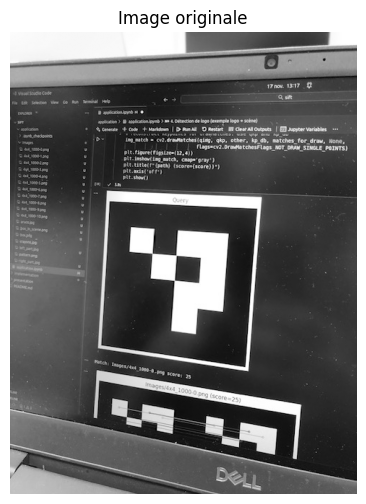

Match: Images/4x4_1000-9.png score: 86


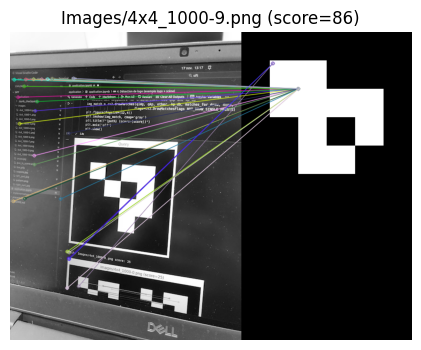

Match: Images/4x4_1000-10.png score: 51


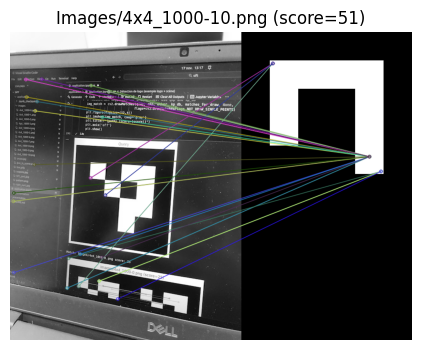

Match: Images/4x4_1000-1.png score: 44


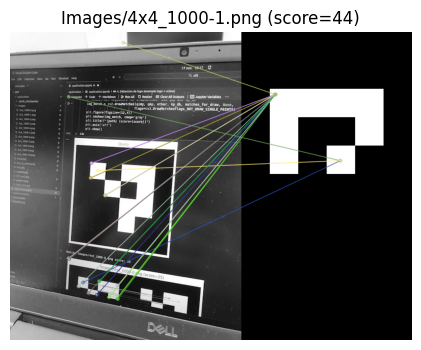

Match: Images/4x4_1000-6.png score: 43


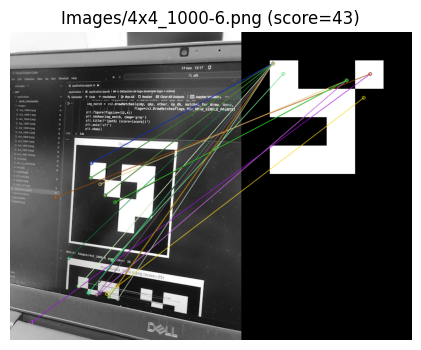

Match: Images/4x4_1000-3.png score: 29


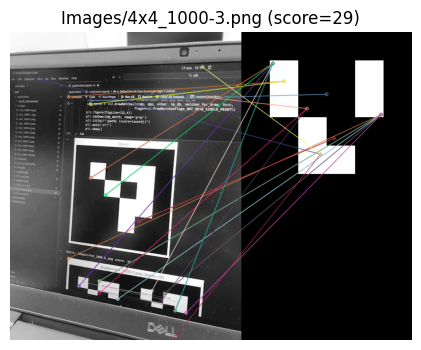

Match: Images/4x4_1000-4.png score: 24


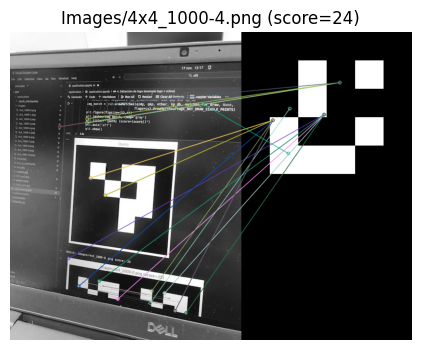

Match: Images/4x4_1000-0.png score: 22


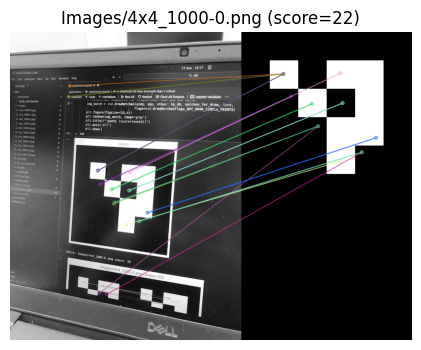

Match: Images/4x4_1000-8.png score: 22


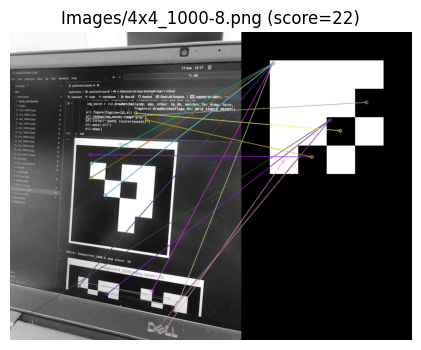

Match: Images/4x4_1000-2.png score: 19


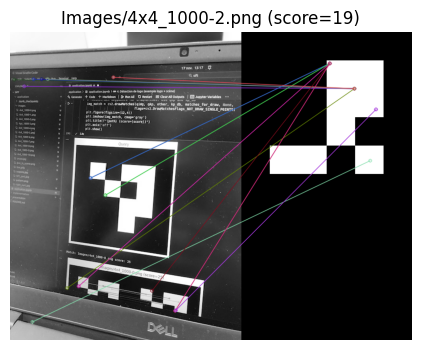

Match: Images/4x4_1000-5.png score: 10


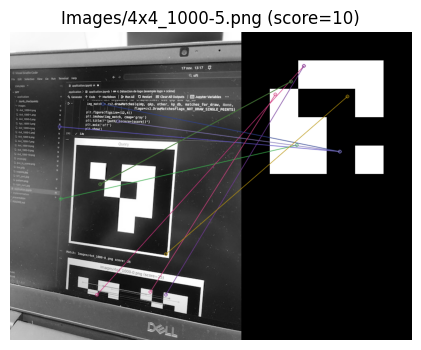

Match: Images/4x4_1000-7.png score: 9


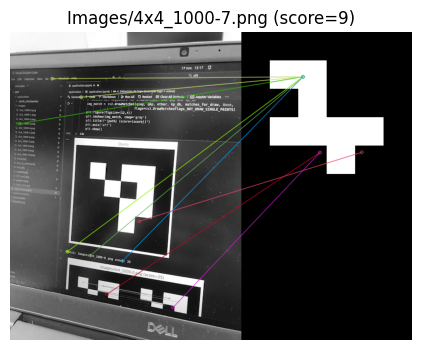

In [15]:
db_files = [path_images + "4x4_1000-0.png", 
            path_images + "4x4_1000-1.png", 
            path_images + "4x4_1000-2.png", 
            path_images + "4x4_1000-3.png", 
            path_images + "4x4_1000-4.png", 
            path_images + "4x4_1000-5.png", 
            path_images + "4x4_1000-6.png", 
            path_images + "4x4_1000-7.png", 
            path_images + "4x4_1000-8.png", 
            path_images + "4x4_1000-9.png", 
            path_images + "4x4_1000-10.png"]
query_file = path_images + "aruco_2.jpg"

sift = cv2.SIFT_create()
# index DB
db = []
for f in db_files:
    img = cv2.imread(f, 0)
    kp, des = sift.detectAndCompute(img, None)
    db.append((f, kp, des, img))

qimg = cv2.imread(query_file, 0)
qkp, qdes = sift.detectAndCompute(qimg, None)

bf = cv2.BFMatcher()
scores = []
for path, kp, des, img in db:
    if des is None or qdes is None:
        scores.append((path, 0, None))
        continue
    matches = bf.knnMatch(qdes, des, k=2)
    good = [m for m,n in matches if m.distance < 0.75 * n.distance]
    scores.append((path, len(good), (kp, good)))

scores.sort(key=lambda x: x[1], reverse=True)

# afficher query et top matches avec keypoints correspondants
plt.figure(figsize=(6,6))
plt.imshow(qimg, cmap='gray')
plt.title("Image originale")
plt.axis('off')
plt.show()

for path, score, info in scores:
    print("Match:", path, "score:", score)
    if info is None:
        continue
    kp_db, good = info
    # draw matches between query and this db image (top 30)
    other = cv2.imread(path, 0)
    drawN = min(30, len(good))
    # need to rebuild pairwise matches objects for drawMatches; create fake DMatch list
    matches_for_draw = []
    for m in good[:drawN]:
        matches_for_draw.append(m)
    # reconstruct keypoints for drawMatches: use qkp and kp_db
    img_match = cv2.drawMatches(qimg, qkp, other, kp_db, matches_for_draw, None,
                               flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(12,4))
    plt.imshow(img_match, cmap='gray')
    plt.title(f"{path} (score={score})")
    plt.axis('off')
    plt.show()

In [16]:
def augment_reality(scene_path, object_path, overlay_path):
    """
    Réalité augmentée : colle une image (overlay) sur une surface détectée dans une scène.

    :param scene_path: Chemin de l'image de la scène.
    :param object_path: Chemin de l'image de l'objet à détecter.
    :param overlay_path: Chemin de l'image à coller sur la surface détectée.
    """
    # Charger les images
    scene = cv2.imread(scene_path)
    object_img = cv2.imread(object_path)
    overlay = cv2.imread(overlay_path)

    if scene is None or object_img is None or overlay is None:
        raise FileNotFoundError("Une ou plusieurs images n'ont pas été trouvées.")

    # Convertir en niveaux de gris
    gray_scene = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
    gray_object = cv2.cvtColor(object_img, cv2.COLOR_BGR2GRAY)

    # Détecter les keypoints et descripteurs avec SIFT
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(gray_object, None)
    kp2, des2 = sift.detectAndCompute(gray_scene, None)

    # Matcher les descripteurs avec FLANN
    flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    matches = flann.knnMatch(des1, des2, k=2)

    # Appliquer le ratio test de Lowe
    good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

    if len(good_matches) < 10:
        print("Pas assez de correspondances pour détecter l'objet.")
        return

    # Trouver l'homographie
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    if M is None:
        print("Homographie introuvable.")
        return

    # Transformer l'image overlay pour qu'elle corresponde à la surface détectée
    h, w, _ = object_img.shape
    overlay_corners = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
    transformed_corners = cv2.perspectiveTransform(overlay_corners, M)

    # Appliquer la transformation
    overlay_warped = cv2.warpPerspective(overlay, M, (scene.shape[1], scene.shape[0]))

    # Créer un masque pour l'overlay
    mask = np.zeros_like(scene, dtype=np.uint8)
    cv2.fillPoly(mask, [np.int32(transformed_corners)], (255, 255, 255))

    # Combiner les images
    mask_inv = cv2.bitwise_not(mask)
    scene_bg = cv2.bitwise_and(scene, mask_inv)
    overlay_fg = cv2.bitwise_and(overlay_warped, mask)
    augmented_scene = cv2.add(scene_bg, overlay_fg)

    # Afficher le résultat
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(augmented_scene, cv2.COLOR_BGR2RGB))
    plt.title("Réalité augmentée")
    plt.axis('off')
    plt.show()

# Exemple d'utilisation
# augment_reality('Images/scene.jpg', 'Images/object.jpg', 'Images/overlay.jpg')

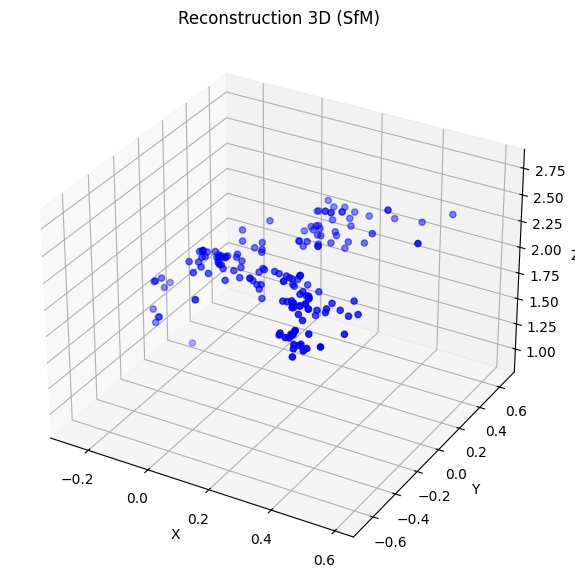

In [17]:
import cv2
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

def structure_from_motion(image_paths):
    """
    Implémente une version simplifiée de Structure from Motion (SfM).
    
    :param image_paths: Liste des chemins des images.
    """
    if len(image_paths) < 2:
        print("Il faut au moins deux images pour calculer la structure 3D.")
        return

    # Charger les images
    images = [cv2.imread(path, cv2.IMREAD_GRAYSCALE) for path in image_paths]
    if any(img is None for img in images):
        print("Une ou plusieurs images n'ont pas pu être chargées.")
        return

    # Initialiser SIFT
    sift = cv2.SIFT_create()

    # Détecter les keypoints et descripteurs pour chaque image
    keypoints = []
    descriptors = []
    for img in images:
        kp, des = sift.detectAndCompute(img, None)
        keypoints.append(kp)
        descriptors.append(des)

    # Matcher les points entre la première et la deuxième image
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(descriptors[0], descriptors[1], k=2)

    # Appliquer le ratio test de Lowe
    good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
    if len(good_matches) < 8:
        print("Pas assez de correspondances entre les deux premières images.")
        return

    # Extraire les points correspondants
    pts1 = np.float32([keypoints[0][m.queryIdx].pt for m in good_matches]).reshape(-1, 2).T
    pts2 = np.float32([keypoints[1][m.trainIdx].pt for m in good_matches]).reshape(-1, 2).T

    # Calculer la matrice essentielle
    K = np.array([[1000, 0, images[0].shape[1] / 2],
                  [0, 1000, images[0].shape[0] / 2],
                  [0, 0, 1]], dtype=np.float32)  # Matrice intrinsèque simplifiée
    E, mask = cv2.findEssentialMat(pts1.T, pts2.T, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)

    # Récupérer la pose relative entre les deux vues
    _, R, t, mask_pose = cv2.recoverPose(E, pts1.T, pts2.T, K)

    # Trianguler les points pour obtenir les coordonnées 3D
    proj1 = np.dot(K, np.hstack((np.eye(3), np.zeros((3, 1)))))
    proj2 = np.dot(K, np.hstack((R, t)))
    points_4d_hom = cv2.triangulatePoints(proj1, proj2, pts1, pts2)
    points_3d = points_4d_hom[:3] / points_4d_hom[3]  # Convertir en coordonnées 3D

    # Afficher les points 3D
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points_3d[0], points_3d[1], points_3d[2], c='b', marker='o')
    ax.set_title("Reconstruction 3D (SfM)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

# Exemple d'utilisation
structure_from_motion(['Images/image8.jpeg', 'Images/image0.jpeg', 'Images/image1.jpeg'])

In [18]:
import cv2
import numpy as np
import plotly.graph_objects as go

def structure_from_motion_interactive(image_paths):
    """
    Implémente une version simplifiée de Structure from Motion (SfM) avec un nuage de points interactif.
    
    :param image_paths: Liste des chemins des images.
    """
    if len(image_paths) < 2:
        print("Il faut au moins deux images pour calculer la structure 3D.")
        return

    # Charger les images
    images = [cv2.imread(path, cv2.IMREAD_GRAYSCALE) for path in image_paths]
    if any(img is None for img in images):
        print("Une ou plusieurs images n'ont pas pu être chargées.")
        return

    # Initialiser SIFT
    sift = cv2.SIFT_create()

    # Détecter les keypoints et descripteurs pour chaque image
    keypoints = []
    descriptors = []
    for img in images:
        kp, des = sift.detectAndCompute(img, None)
        keypoints.append(kp)
        descriptors.append(des)

    # Matcher les points entre la première et la deuxième image
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(descriptors[0], descriptors[1], k=2)

    # Appliquer le ratio test de Lowe
    good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
    if len(good_matches) < 8:
        print("Pas assez de correspondances entre les deux premières images.")
        return

    # Extraire les points correspondants
    pts1 = np.float32([keypoints[0][m.queryIdx].pt for m in good_matches]).reshape(-1, 2).T
    pts2 = np.float32([keypoints[1][m.trainIdx].pt for m in good_matches]).reshape(-1, 2).T

    # Calculer la matrice essentielle
    K = np.array([[1000, 0, images[0].shape[1] / 2],
                  [0, 1000, images[0].shape[0] / 2],
                  [0, 0, 1]], dtype=np.float32)  # Matrice intrinsèque simplifiée
    E, mask = cv2.findEssentialMat(pts1.T, pts2.T, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)

    # Récupérer la pose relative entre les deux vues
    _, R, t, mask_pose = cv2.recoverPose(E, pts1.T, pts2.T, K)

    # Trianguler les points pour obtenir les coordonnées 3D
    proj1 = np.dot(K, np.hstack((np.eye(3), np.zeros((3, 1)))))
    proj2 = np.dot(K, np.hstack((R, t)))
    points_4d_hom = cv2.triangulatePoints(proj1, proj2, pts1, pts2)
    points_3d = points_4d_hom[:3] / points_4d_hom[3]  # Convertir en coordonnées 3D

    # Créer un nuage de points interactif avec Plotly
    fig = go.Figure(data=[go.Scatter3d(
        x=points_3d[0],
        y=points_3d[1],
        z=points_3d[2],
        mode='markers',
        marker=dict(size=3, color=points_3d[2], colorscale='Viridis', opacity=0.8)
    )])
    fig.update_layout(scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    title="Reconstruction 3D Interactif (SfM)")
    fig.show()

# Exemple d'utilisation

structure_from_motion_interactive(['Images/image8.jpeg', 'Images/image0.jpeg', 'Images/image1.jpeg'])